# Image Processing with OpenCV

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Changing Color-Space
Convert images from one color space to another, like BGR to Gray, HSV etc

### HSV Video for Blue

In [3]:
cap = cv.VideoCapture(0)
 
while(1):
 
    # Take each frame
    _, frame = cap.read()
 
    # Convert BGR to HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
 
    # define range of blue color in HSV
    lower_blue = np.array([110,50,50])
    upper_blue = np.array([130,255,255])
 
    # Threshold the HSV image to get only blue colors - Mask where blue areas are white
    mask = cv.inRange(hsv, lower_blue, upper_blue)
 
    # Bitwise-AND mask and original image - Keeps blue, rest black
    res = cv.bitwise_and(frame,frame, mask= mask)
 
    cv.imshow('frame',frame)
    cv.imshow('mask',mask)
    cv.imshow('res',res)
    k = cv.waitKey(5) & 0xFF
    if k == 27:
        break
 
cv.destroyAllWindows()
cap.release()

**HSV - Hue, Saturation, Value**
1. Hue - Type of color (0-179)
2. Saturation - How pure the color is (0-255)
3. Value - How bright the color is (0-255)

- 110 Hue for dark/starting blue

- 130 Hue for light/ending blue

### Hue, Saturation, Value Visualization

In [4]:
# Callback function (required for createTrackbar)
def nothing(x):
    pass

# Create a named window
cv.namedWindow("HSV Color Viewer")

# Create trackbars for Hue, Saturation, and Value
cv.createTrackbar("Hue", "HSV Color Viewer", 120, 179, nothing)         # Hue: 0-179
cv.createTrackbar("Saturation", "HSV Color Viewer", 255, 255, nothing)  # Saturation: 0-255
cv.createTrackbar("Value", "HSV Color Viewer", 255, 255, nothing)       # Value: 0-255

while True:
    # Get current trackbar positions
    h = cv.getTrackbarPos("Hue", "HSV Color Viewer")
    s = cv.getTrackbarPos("Saturation", "HSV Color Viewer")
    v = cv.getTrackbarPos("Value", "HSV Color Viewer")

    # Create an HSV pixel and convert to BGR for display
    hsv_color = np.uint8([[[h, s, v]]])  # 1x1 pixel
    bgr_color = cv.cvtColor(hsv_color, cv.COLOR_HSV2BGR)
    bgr_image = np.full((200, 400, 3), bgr_color[0][0], dtype=np.uint8)  # Fill whole image with color

    # Show the color
    cv.imshow("HSV Color Viewer", bgr_image)

    # Exit on ESC
    if cv.waitKey(1) & 0xFF == 27:
        break

cv.destroyAllWindows()

### For Grayscale Video

In [5]:
cap = cv.VideoCapture(0)

while True:
    ret, frame = cap.read() # ret means if Frame captured successfully!
    if not ret:
        break

    # Convert to grayscale
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # Show original frame
    cv.imshow('Color Frame', frame)
    # Show grayscale frame
    cv.imshow('Grayscale Frame', gray)

    # Exit on ESC key
    if cv.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv.destroyAllWindows()

## Geometric Transformation of Images
Transform images with translation, rotation, scaling, affine transformation

### Scaling

In [7]:
import cv2 as cv

img = cv.imread('images/image.jpeg')
assert img is not None, "file could not be read, check with os.path.exists()"

height, width = 400, 600

img_resize = cv.resize(img, (width, height))

explicit = True

if not explicit:
    print("Non-Explicit Running")

    # Resize using scale factors (doubling the size)
    res_fx_fy = cv.resize(img_resize, None, fx=2, fy=2, interpolation=cv.INTER_CUBIC)

    # Show original and scaled images
    cv.imshow('Original', img_resize)
    cv.imshow('Scaled (using fx, fy)', res_fx_fy)
    cv.waitKey(0)
    cv.destroyAllWindows()

# OR

if explicit:
    print("Explicit Running")

    # Resize using explicit size (doubling width and height)
    res_explicit = cv.resize(img_resize, (2 * width, 2 * height), interpolation=cv.INTER_CUBIC)

    # Show original and scaled images again
    cv.imshow('Original', img_resize)
    cv.imshow('Scaled (using explicit size)', res_explicit)
    cv.waitKey(0)
    cv.destroyAllWindows()

Explicit Running


### Translation

In [10]:
img = cv.imread('images/image.jpeg', cv.IMREAD_GRAYSCALE)
img = cv.resize(img, (width, height))

assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols = height, width # Output image size
# rows,cols = img.shape
 
M = np.float32([[1,0,100],[0,1,50]])
dst = cv.warpAffine(img,M,(cols,rows))
 
cv.imshow('translated',dst)
cv.imshow('img', img)
cv.waitKey(0)
cv.destroyAllWindows()

### Rotation

In [11]:
img = cv.imread('images/image.jpeg', cv.IMREAD_GRAYSCALE)
img = cv.resize(img, (600, 400))
assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols = 400, 600
 
# cols-1 and rows-1 are the coordinate limits.
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),90,1)
dst = cv.warpAffine(img,M,(cols,rows))

cv.imshow('Original Image', img)
cv.imshow('Rotated Image (90 degrees)', dst)

cv.waitKey(0)
cv.destroyAllWindows()

### Affine Transformation
All parallel lines remain as such in the output

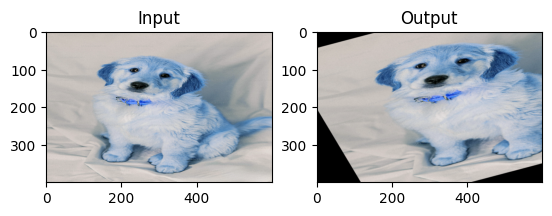

In [12]:
img = cv.imread('images/image.jpeg')
img = cv.resize(img, (600, 400))

assert img is not None, "file could not be read, check with os.path.exists()"
rows,cols,ch = 400, 600, 3
 
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])
 
M = cv.getAffineTransform(pts1,pts2)
 
dst = cv.warpAffine(img,M,(cols,rows))
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')
plt.show()

Sudoku Example, Grid Mapping

## Image Thresholding

### Simple Threshold

- Applies fixed value to every pixel in grayscale
    - If px > threshold, set to max
    - Else, Set to 0 or modified based on type

- Types:

    1. `cv2.THRESH_BINARY` ➡️ px > thresh: maxval, else 0

    2. `cv2.THRESH_BINARY_INV` ➡️ Inverse of thresh binary

    3. `cv2.THRESH_TRUNC` ➡️ px > thresh: thresh, else original

    4. `cv2.THRESH_TOZERO` ➡️ px > thresh: original, else 0

    5. `cv2.THRESH_TOZERO_INV` ➡️ Inverse of thresh to zero

- Way to convert grayscale to black and white, binary image

- Pick a threshold value, if pixel **brighter** than threshold, make it white

- If pixel is **darker** that threshold, make it black

- Use case: Separate objects from background, detect shapes, contour detection

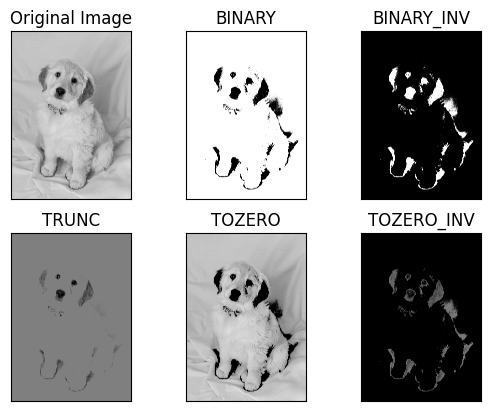

In [13]:
img = cv.imread('images/image.jpeg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
ret,thresh1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
ret,thresh2 = cv.threshold(img,127,255,cv.THRESH_BINARY_INV)
ret,thresh3 = cv.threshold(img,127,255,cv.THRESH_TRUNC)
ret,thresh4 = cv.threshold(img,127,255,cv.THRESH_TOZERO)
ret,thresh5 = cv.threshold(img,127,255,cv.THRESH_TOZERO_INV)
# Threshold of 127
 
titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
 
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
 
plt.show()

### Adaptive Thresholding

- Calculates threshold for each pixel based on brightness of its local neighborhood

- When to use?
    - Uneven lighting

    - Some areas bright, some dark

    - Global threshold like in Simple Thresholding might not work

- How it works?
    - Looks at small region (called a block)

    - Calculate threshold for that region
        - `cv.ADAPTIVE_THRESH_MEAN_C`
        - `cv.ADAPTIVE_THRESH_GAUSSIAN_C`

    - Compares pixel for that local threshold

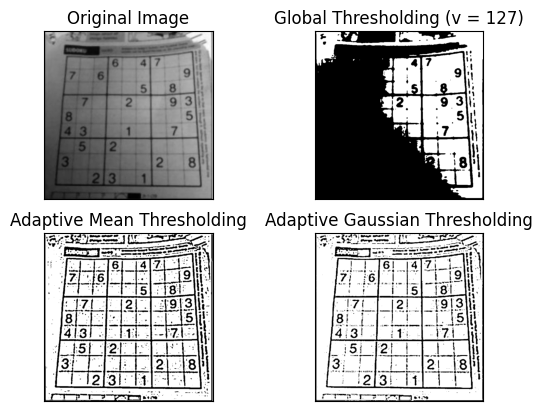

In [14]:
img = cv.imread('images/sudoku.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
img = cv.medianBlur(img,5) 
# Median Blur, Kernel Size of 5, Replace px with median of neighbors
 
ret,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_MEAN_C,\
            cv.THRESH_BINARY,11,2) 
            # Threshold is mean of 11*11 neighborhood, minus 2
            # Minus 2 decreases the threshold slightly
th3 = cv.adaptiveThreshold(img,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv.THRESH_BINARY,11,2)
            # Threshold is weighted (gaussian) sum, when dealing with smooth gradients
 
titles = ['Original Image', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [img, th1, th2, th3]
 
for i in range(4):
    plt.subplot(2,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

### Otsu's Binarization

- Advanced automatic global thresholding

- Finds best threshold value from image histogram
    - Threshold that minimizes intra-class variance (Spread within foreground & background)

- Works well on bimodal images (Images with 2 main brightness levels)

- Useful when threshold value is hard to pick

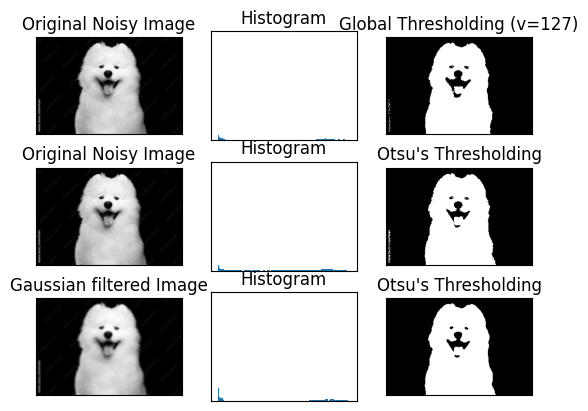

In [15]:
img = cv.imread('images/samo.jpeg', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 
# global thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
 
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# Otsu's thresholding after Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
 
# plot all the images and their histograms
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Original Noisy Image','Histogram','Global Thresholding (v=127)',
          'Original Noisy Image','Histogram',"Otsu's Thresholding",
          'Gaussian filtered Image','Histogram',"Otsu's Thresholding"]
 
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

## Smoothing Images
Make image less sharp or less noisy by averaging out pixel values

Blur images with low pass filters, apply custom-made filters

### Purpose of Image Filtering (Convolution)
- For blurring, noise reduction, edge detection

- Involves sliding a kernel (filter matrix) over the image and computing dot products

**2D Convolution** using `cv.filter2D()`
- Applies any custom kernel to the image

- Useful for both low-pass (blur) and high-pass (edge detection) filters

In [16]:
# Average Filter with 5 * 5 Kernel

img = cv.imread("images/dog.jpeg")
img = cv.resize(img, (300, 200))

# 5 * 5 Matrix with 1s
kernel = np.ones((5,5), np.float32) / 25 # Normalized Average Filter

dst = cv.filter2D(img, -1, kernel) 

Takes the 25 pixels and multiplies with kernel values, adds them up and set average as new pixel value for center pixel only

Center pixel in kernel window is replaced by average of its neighboring 5 * 5 pixels

Entire image gets smooth, blurred effect

In [ ]:
cv.imshow("Kernel Pic", dst)
cv.waitKey(0)
cv.destroyAllWindows()

# Replace each pixel with average of its 5 * 5 neighborhood

### Image Blurring Techniques
1. **Averaging**
- Replaces pixel with mean of neighbors

- Very basic, blurs everything equally

In [ ]:
blur = cv.blur(img, (5,5)) # Automatically uses Normalized Kernel

cv.imshow("Blurred", blur)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
boxfilt = cv.boxFilter(img, -1, (5,5), normalize=True) 
# More Customizable

cv.imshow("Box Filter", boxfilt)
cv.waitKey(0)
cv.destroyAllWindows()

**2. Gaussian Blur**
- Uses Gaussian Kernel (Bell Shaped Kernel)

- Natural looking blur, for Gaussian Noise

- Digital images, Scientific data

In [ ]:
gauss = cv.GaussianBlur(img, (5,5), 0) # sigmaX: Std Dev in X direction, sigmaY
# 0 means automatically calculate the std dev from the kernel size

cv.imshow("Gaussian Blur", gauss)
cv.waitKey(0)
cv.destroyAllWindows()

**3. Median Blur**
- Replaces central pixel with median of its neighbors

- For salt-pepper noises
    - Impulse noise, random white (salt) and black (pepper) are pixels scatterred over an image

In [ ]:
medi = cv.medianBlur(img, 5) # Kernel must be positive odd interger

cv.imshow("Median Blur", medi)
cv.waitKey(0)
cv.destroyAllWindows() # Output pixel is from original image

**4. Bilateral Filter**
- Preserves edges while smoothing similar-intensity pixels

- Slow but best for edge preserving smoothing

- Edge Preservation
    - Does smoothing
    
    - Keeps the important details: Boundaries, shapes etc

In [ ]:
bilat = cv.bilateralFilter(img, 9, 75, 75) 

`(image, diameter, sigmaColor, sigmaSpace)` 
- `diameter`: Diameter of each pixel neighborhood, 9 x 9 Kernel

- `sigmaColor`: Std dev in color space
    - Small: Only very similar colors mix

    - Large: Wider color differences allowed

- `sigmaSpace`: Std dev in coordinate space
    - Small: Only nearby pixels influence 

    - Large: Farther pixels influence smoothing


In [ ]:
cv.imshow("Bilateral Filter", bilat)
cv.waitKey(0)
cv.destroyAllWindows()

## Morphological Transformation
Simple operations based on shape of objects in image

Applied in binary images (foreground = white, background = black)

### 1. Erosion
- Shrinks white regions (foreground)

- Kernel slides over image and pixel remains white if all pixels under kernel are white, else becomes black

- Removes small white noise, reduces object size

In [ ]:
kernel = np.ones((5,5), np.uint8)

erosion = cv.erode(img, kernel, iterations=1)

cv.imshow("Erosion", erosion)
cv.waitKey(0)
cv.destroyAllWindows()

### 2. Dilation
- Expands white regions (foreground)

- Pixel becomes white if at least one pixel under kernel is white

- Enlarge objects, fill small holes, joins broken parts

In [ ]:
dilation = cv.dilate(img, kernel, iterations=1)

cv.imshow("Dilation", dilation)
cv.waitKey(0)
cv.destroyAllWindows()

### 3. Opening
- Erosion followed by Dilation

- Removes noise (small white spots) while preserving object shape and size

In [ ]:
opening = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)

cv.imshow("Opening", opening)
cv.waitKey(0)
cv.destroyAllWindows()

### 4. Closing
- Dilation followed by Erosion

- Close small holes or black spots

In [ ]:
closing = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel)

cv.imshow("Closing", closing)
cv.waitKey(0)
cv.destroyAllWindows()

### 5. Morphological Gradient
- Difference between dilation and erosion of an image

- Highlights the outline or edgess of objects

In [ ]:
gradient = cv.morphologyEx(img, cv.MORPH_GRADIENT, kernel)

cv.imshow("Gradient", gradient)
cv.waitKey(0)
cv.destroyAllWindows()

### 6. Top Hat
- Difference between original and its opening

- Extract small bright elements on a dark background

In [ ]:
tophat = cv.morphologyEx(img, cv.MORPH_TOPHAT, kernel)

cv.imshow("Top Hat", tophat)
cv.waitKey(0)
cv.destroyAllWindows()

### 7. Black Hat 
- Difference between closing of image and original image

- Extracts small dark elements on bright background

In [ ]:
blackhat = cv.morphologyEx(img, cv.MORPH_BLACKHAT, kernel)

cv.imshow("Black Hat", blackhat)
cv.waitKey(0)
cv.destroyAllWindows()

### **Able to structure element (kernel) shapes**

Rectangular kernel

`cv.getStructuringElement(cv.MORPH_RECT, (5,5))`
- General purpose, strong effect on all sides

Elliptical kernel

`cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))`
- Smooths edges naturally, for circular objects

Cross-shaped kernel

`cv.getStructuringElement(cv.MORPH_CROSS, (5,5))`
- Strong effect in vertical and horizontal directions, preserves corners

## Image Gradients

**1. Gradient Filters (High-Pass Filters)**
- Highlight regions of rapid intensity change (edges)
    - Sobel Operator
        - Edge in specific direction (left-right or up-down)
        - Able to choose direction x-direction, y-direction
        - First derivative in x/y direction
    - Scharr Operator
        - Variation of sobel, `ksize` = -1
    - Laplacian Operator
        - All edges in all directions at once
        - Uses second order derivative (more sensitive to noise)

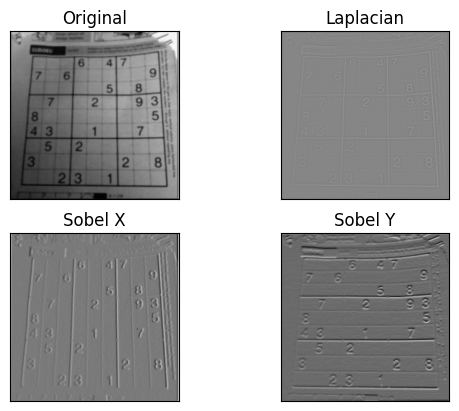

In [17]:
img = cv.imread('images/sudoku.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"
 
laplacian = cv.Laplacian(img,cv.CV_64F)
sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=5)
sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=5)
 
plt.subplot(2,2,1),plt.imshow(img,cmap = 'gray')
plt.title('Original'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,2),plt.imshow(laplacian,cmap = 'gray')
plt.title('Laplacian'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,3),plt.imshow(sobelx,cmap = 'gray')
plt.title('Sobel X'), plt.xticks([]), plt.yticks([])
plt.subplot(2,2,4),plt.imshow(sobely,cmap = 'gray')
plt.title('Sobel Y'), plt.xticks([]), plt.yticks([])
 
plt.show()

## Canny Edge Detection

**Powerful algorithm to find edges in images, step by step filter that finds only important clean edges and removes the noise**

1. Noise Reduction
    - Images can be noisy (random dots, small patterns)
    - Image smoothed using 5 * 5 Gaussian Blur

2. Find Image Gradient
    - Use Sobel filters to find changes in brightness (edges)
        - Gx, Gy

3. Non-Maximum Supresssion
    - Keep only strongest edge pixels (local maxima)
    - Makes edges look thin and sharp

4. Hysteresis Thresholding
    - Use thresholds: minVal & maxVal
    - Px with gradient > maxVal are strong edges
    - Px < minVal are ignored, non-edges
    - Px in between are maybe edges
        - If connected to strong edge > keep
        - Else discard

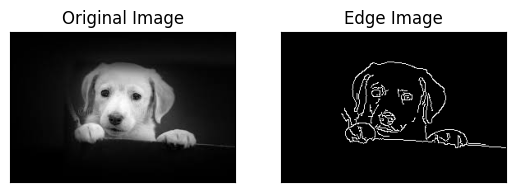

In [18]:
# Read grayscale image
img = cv.imread('images/dog.jpeg', cv.IMREAD_GRAYSCALE)
assert img is not None, "Image not found."

# Apply Canny Edge Detection
edges = cv.Canny(img, 100, 200)

# Display original and edge images
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edge Image')
plt.xticks([]), plt.yticks([])
plt.show()

## Contours and Histogram in OpenCV

**Contours**
- Curves that connect continuous point along boundary of objects with same color or intensity

- Shape analysis, object detection and recognition

In [19]:
# Load image
img = cv.imread('images/dog.jpeg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply threshold
ret, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Find contours
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Draw contours
cv.drawContours(img, contours, -1, (0, 255, 0), 2)

# Display result
cv.imshow('Contours', img)
cv.waitKey(0)
cv.destroyAllWindows()

**Histograms**
- Graphical representation of distribution of pixel intensities in an image

- Show how many pixels have each intensity value

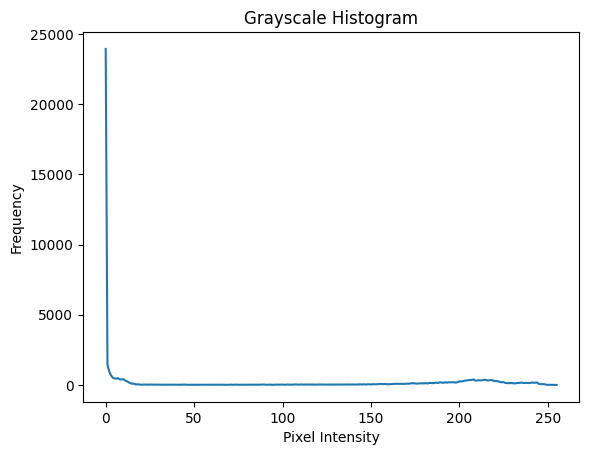

In [20]:
# Load image
img = cv.imread('images/samo.jpeg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Calculate histogram
hist = cv.calcHist([gray], [0], None, [256], [0, 256])

# Plot histogram
plt.plot(hist)
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

# 0 - Dark/Black, 255 - White/Bright